In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
import pandas as pd
import numpy as np
import os
import cv2
from tqdm import tqdm
from PIL import Image
from keras.preprocessing.image import load_img

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from keras.models import Sequential, Model
from keras.layers import Dense , Conv2D , Dropout, Flatten, MaxPooling2D , Input
from tensorflow.keras.utils import plot_model
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.initializers import random_uniform, glorot_uniform, constant, identity
from tensorflow.keras.layers import Add, BatchNormalization, GlobalMaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import datasets,layers, models
from tensorflow.keras.models import Model

In [7]:
BASE_DIR = ['/kaggle/input/utkface-new/UTKFace']

In [8]:
image_paths = []
ages = []
genders = []

In [9]:
for base_dir in BASE_DIR:
    for filename in tqdm(os.listdir(base_dir)):
        temp = filename.split('_')
        if len(temp) >= 2 and temp[0].isdigit():
            age = int(temp[0])
            gender = int(temp[1])
            image_path = os.path.join(base_dir,filename)
            image_paths.append(image_path)    
            ages.append(age)
            genders.append(gender)
            

100%|██████████| 23708/23708 [00:00<00:00, 471292.90it/s]


In [10]:
df = pd.DataFrame({
    'image': image_paths,
    'age': ages,
    'gender': genders
})
df.head()

,image,age,gender
0,/kaggle/input/utkface-new/UTKFace/26_0_2_20170...,26,0
1,/kaggle/input/utkface-new/UTKFace/22_1_1_20170...,22,1
2,/kaggle/input/utkface-new/UTKFace/21_1_3_20170...,21,1
3,/kaggle/input/utkface-new/UTKFace/28_0_0_20170...,28,0
4,/kaggle/input/utkface-new/UTKFace/17_1_4_20170...,17,1


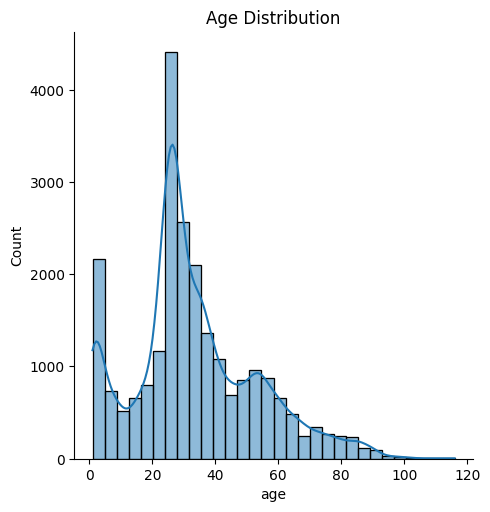

In [11]:
sns.displot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

In [12]:
def extract_features(images):
    features = []
    for img_path in tqdm(images):
        img = Image.open(img_path).convert('L')
        img = img.resize((128,128))
        img = np.array(img)
        features.append(img)
    features = np.array(features)
    features = features.reshape(len(features),128,128,1)
    return features

X = extract_features(df['image'])
X = X / 255.0

y_gender = np.array(df['gender'])
y_age = np.array(df['age'])


print("shape of y_gender:",y_gender.shape)
print("shape of y_age:",y_age.shape)

100%|██████████| 23708/23708 [03:07<00:00, 126.17it/s]


shape of y_gender: (23708,)
shape of y_age: (23708,)


In [13]:
y_combined = np.column_stack((y_gender, y_age))

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_combined, test_size=0.2, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

y_train_gender, y_train_age = y_train[:,0], y_train[:,1]
y_val_gender, y_val_age = y_val[:,0], y_val[:,1]


In [14]:
inputs = Input(shape=(128,128,1))

x = Conv2D(32, (3,3), activation='relu')(inputs)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

x = Flatten()(x)

gender_branch = Dense(256, activation='relu')(x)
gender_branch = Dropout(0.3)(gender_branch)
gender_output = Dense(1, activation='sigmoid', name='gender_out')(gender_branch)

age_branch = Dense(256, activation='relu')(x)
age_branch = Dropout(0.3)(age_branch)
age_output = Dense(1, activation='relu', name='age_out')(age_branch)

model = Model(inputs, [gender_output, age_output])
model.summary()


I0000 00:00:1770181120.039170     141 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  6,422,784 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │  6,422,784 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_out (Dense)  │ (None, 1)         │        257 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_out (Dense)     │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,938,754 (49.36 MB)

 Trainable params: 12,938,754 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from tensorflow.keras.callbacks import LearningRateScheduler
model.compile(
    optimizer='adam',
    loss=['binary_crossentropy','mae'],
    metrics=['accuracy','mae']
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_gender_out_accuracy',
    save_best_only=True,
    mode='max'
)

lr_scheduler = LearningRateScheduler(lambda e: 1e-3 * 0.9 ** e)

history = model.fit(
    X_train,
    [y_train_gender, y_train_age],
    validation_data=(X_val,[y_val_gender,y_val_age]),
    epochs=100,
    batch_size=128,
    callbacks=[checkpoint, lr_scheduler]
)


Epoch 1/100


I0000 00:00:1770181134.279440     262 service.cc:152] XLA service 0x7b599800f3c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770181134.279503     262 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770181134.808791     262 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/149 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - age_out_loss: 27.3412 - age_out_mae: 27.3412 - gender_out_accuracy: 0.5233 - gender_out_loss: 1.1171 - loss: 28.4584

I0000 00:00:1770181140.063355     262 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


149/149 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - age_out_loss: 17.8561 - age_out_mae: 17.8563 - gender_out_accuracy: 0.5980 - gender_out_loss: 0.7602 - loss: 18.6165 - val_age_out_loss: 14.3476 - val_age_out_mae: 14.3668 - val_gender_out_accuracy: 0.7360 - val_gender_out_loss: 0.5421 - val_loss: 14.9076 - learning_rate: 0.0010
Epoch 2/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - age_out_loss: 12.8364 - age_out_mae: 12.8365 - gender_out_accuracy: 0.7622 - gender_out_loss: 0.4986 - loss: 13.3351 - val_age_out_loss: 10.6579 - val_age_out_mae: 10.7015 - val_gender_out_accuracy: 0.8140 - val_gender_out_loss: 0.4060 - val_loss: 11.1064 - learning_rate: 9.0000e-04
Epoch 3/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - age_out_loss: 10.4619 - age_out_mae: 10.4619 - gender_out_accuracy: 0.8252 - gender_out_loss: 0.3882 - loss: 10.8501 - val_age_out_loss: 9.8446 - val_age_out_mae: 9.8818 - val_gender_out_accuracy: 0.8439 - val_gender_out_loss: 0.3392 - val_loss: 10.2201 - learning_rate: 8.1000e-

In [16]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

In [32]:
def detect_hair_length_kaggle(image_path):
    # Safety checks
    if not isinstance(image_path, str):
        raise TypeError("Expected image_path as string")

    image_path = image_path.strip()

    if not os.path.exists(image_path):
        raise FileNotFoundError(image_path)

    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("cv2.imread failed")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    if len(faces) == 0:
        return "Short"

    x, y, w, h = faces[0]
    img_h, img_w = img.shape[:2]

    # Vertical hair
    vertical_long = (y + int(1.6 * h)) < img_h

    # Side hair
    left_space = x
    right_space = img_w - (x + w)
    horizontal_long = left_space > 0.15 * w or right_space > 0.15 * w

    # Texture
    cheek = gray[y+int(0.3*h):y+int(0.7*h), x:x+w]
    texture_long = np.var(cheek) > 150

    return "Long" if (vertical_long or horizontal_long or texture_long) else "Short"


In [33]:
gender_dict = {0:'Male', 1:'Female'}

def final_gender_logic(pred_age, model_gender, hair):
    if 20 <= pred_age <= 30:
        return "Female" if hair == "Long" else "Male"
    return model_gender



In [34]:
def predict_final(image_path):
    img = Image.open(image_path).convert('L')
    img = img.resize((128,128))
    img = np.array(img)/255.0
    img = img.reshape(1,128,128,1)

    pred = model.predict(img)
    pred_gender = gender_dict[int(round(pred[0][0][0]))]
    pred_age = int(round(pred[1][0][0]))

    hair = detect_hair_length(image_path)
    final_gender = final_gender_logic(pred_age, pred_gender, hair)

    return pred_age, pred_gender, hair, final_gender


<class 'str'>
/kaggle/input/utkface-new/UTKFace/28_0_4_20170116220531686.jpg.chip.jpg
Hair Length: Short


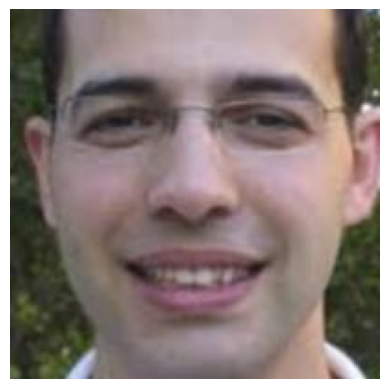

In [35]:
idx = 3000
img_path = df.loc[idx, "image"]   # MUST be string

print(type(img_path))
print(img_path)

hair = detect_hair_length_kaggle(img_path)
print("Hair Length:", hair)

plt.imshow(Image.open(img_path))
plt.axis("off")
plt.show()
